# Comparaison de modèles pour la détection de masque

Notebook de travail séparé pour tester un CNN plus robuste quand le modèle actuel donne de mauvaises prédictions.

Ce notebook compare un modèle CNN simple de référence et un modèle préféré basé sur du transfert learning CNN, sur les classes `with_mask` et `without_mask`.

In [3]:
from pathlib import Path
import json
import os
import subprocess
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

try:
    import kagglehub
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
    import kagglehub

IMAGE_SIZE = 128
CLASS_NAMES = ("with_mask", "without_mask")

PROJECT_ROOT = Path.cwd().resolve()
if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "models").exists():
    pass
elif (PROJECT_ROOT / "plugins" / "mask-detection-cnn").exists():
    PROJECT_ROOT = (PROJECT_ROOT / "plugins" / "mask-detection-cnn").resolve()
else:
    PROJECT_ROOT = Path(r"C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn").resolve()


def resolve_dataset_root(project_root: Path) -> Path:
    local_root = project_root / "data"
    if (local_root / "with_mask").exists() and (local_root / "without_mask").exists():
        return local_root

    download_path = Path(kagglehub.dataset_download("omkargurav/face-mask-dataset"))
    candidates = [download_path, download_path / "data"]

    for candidate in candidates:
        if (candidate / "with_mask").exists() and (candidate / "without_mask").exists():
            return candidate

    for candidate in candidates:
        if candidate.exists():
            for child in candidate.iterdir():
                if child.is_dir() and (child / "with_mask").exists() and (child / "without_mask").exists():
                    return child

    raise FileNotFoundError("Impossible de localiser les dossiers with_mask et without_mask.")


DATASET_ROOT = resolve_dataset_root(PROJECT_ROOT)
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATASET_ROOT =", DATASET_ROOT)
print("MODELS_DIR   =", MODELS_DIR)
print("CLASS_NAMES  =", CLASS_NAMES)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
PROJECT_ROOT = /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn
DATASET_ROOT = /kaggle/input/face-mask-dataset/data
MODELS_DIR   = /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/models
CLASS_NAMES  = ('with_mask', 'without_mask')


In [4]:
def collect_image_paths(dataset_root: Path) -> tuple[list[str], list[str]]:
    image_paths: list[str] = []
    labels: list[str] = []

    for class_name in CLASS_NAMES:
        class_dir = dataset_root / class_name
        if not class_dir.exists():
            continue
        files = sorted([
            *class_dir.glob("*.jpg"),
            *class_dir.glob("*.jpeg"),
            *class_dir.glob("*.png"),
            *class_dir.glob("*.webp"),
        ])
        image_paths.extend(str(path) for path in files)
        labels.extend([class_name] * len(files))

    if not image_paths:
        raise FileNotFoundError(
            "Aucune image trouvée dans le dataset local ou téléchargé. Vérifie la structure du dossier du dataset."
        )

    return image_paths, labels


def load_images(image_paths: list[str]) -> np.ndarray:
    images = []
    for image_path in image_paths:
        image = Image.open(image_path).convert("RGB")
        image = image.resize((IMAGE_SIZE, IMAGE_SIZE))
        images.append(np.asarray(image, dtype=np.float32) / 255.0)
    return np.asarray(images, dtype=np.float32)


image_paths, raw_labels = collect_image_paths(DATASET_ROOT)
X = load_images(image_paths)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(raw_labels)

print("Images:", X.shape)
print("Classes:", list(label_encoder.classes_))
print("Distribution:", np.bincount(y))

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Images: (7553, 128, 128, 3)
Classes: [np.str_('with_mask'), np.str_('without_mask')]
Distribution: [3725 3828]


In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=len(CLASS_NAMES))
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=len(CLASS_NAMES))
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=len(CLASS_NAMES))

print("Train:", X_train.shape, y_train_cat.shape)
print("Val:  ", X_val.shape, y_val_cat.shape)
print("Test: ", X_test.shape, y_test_cat.shape)

Train: (5287, 128, 128, 3) (5287, 2)
Val:   (1133, 128, 128, 3) (1133, 2)
Test:  (1133, 128, 128, 3) (1133, 2)


## 3. Entraîner le modèle actuel

On garde ici un CNN simple comme référence de performance.

In [6]:
def build_current_cnn() -> tf.keras.Model:
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
        tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax'),
    ])


current_model = build_current_cnn()
current_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_current = current_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=5,
    batch_size=32,
    verbose=1,
)

Epoch 1/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.8177 - loss: 0.3884 - val_accuracy: 0.8932 - val_loss: 0.2474
Epoch 2/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.9005 - loss: 0.2393 - val_accuracy: 0.9170 - val_loss: 0.2019
Epoch 3/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.9217 - loss: 0.2024 - val_accuracy: 0.9259 - val_loss: 0.1845
Epoch 4/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.9385 - loss: 0.1595 - val_accuracy: 0.9126 - val_loss: 0.2144
Epoch 5/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.9451 - loss: 0.1359 - val_accuracy: 0.8932 - val_loss: 0.3198


## 4. Évaluer les performances de prédiction

On calcule des métriques simples pour comparer proprement les modèles.


=== Modèle actuel ===
{
  "accuracy": 0.9046778464254193,
  "precision": 0.8819672131147541,
  "recall": 0.9372822299651568,
  "f1": 0.9087837837837838
}
              precision    recall  f1-score   support

   with_mask       0.93      0.87      0.90       559
without_mask       0.88      0.94      0.91       574

    accuracy                           0.90      1133
   macro avg       0.91      0.90      0.90      1133
weighted avg       0.91      0.90      0.90      1133



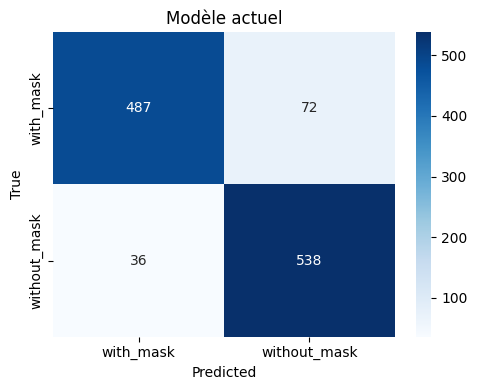

In [7]:
def evaluate_model(model: tf.keras.Model, X_data: np.ndarray, y_true: np.ndarray, title: str) -> dict[str, float]:
    y_prob = model.predict(X_data, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
    }
    print(f"\n=== {title} ===")
    print(json.dumps(metrics, indent=2))
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.show()
    return metrics


current_metrics = evaluate_model(current_model, X_test, y_test, 'Modèle actuel')

## Lecture des résultats

Les métriques affichées juste au-dessus permettent de comparer les modèles avec un peu plus de recul que la seule accuracy.

- `accuracy` indique la part globale de bonnes prédictions.
- `precision` mesure la qualité des prédictions positives et évite de sur-estimer la classe `without_mask`.
- `recall` regarde combien de vrais cas de la classe cible sont retrouvés.
- `f1` résume l'équilibre entre précision et rappel.

La matrice de confusion est importante ici parce qu'elle montre immédiatement si le modèle se trompe surtout en confondant `with_mask` et `without_mask`. Si une case hors diagonale reste élevée, cela signifie qu'il faut renforcer le prétraitement, l'augmentation de données ou la capacité du modèle.

## 5. Comparer avec le modèle préféré

Le modèle préféré ci-dessous reste un CNN, mais avec transfert learning pour améliorer la généralisation.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 103s 580ms/step - accuracy: 0.8088 - loss: 0.4372 - val_accuracy: 0.9603 - val_loss: 0.1213
Epoch 2/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 103s 617ms/step - accuracy: 0.9334 - loss: 0.1661 - val_accuracy: 0.9726 - val_loss: 0.0799
Epoch 3/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 134s 569ms/step - accuracy: 0.9503 - loss: 0.1284 - val_accuracy: 0.9753 - val_loss: 0.0681
Epoch 4/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 141s 564ms/step - accuracy: 0.9542 - loss: 0.1192 - val_accuracy: 0.9753 - val_loss: 0.0618
Epoch 5/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 144s 574ms/step - accuracy: 0.9652 - loss: 0.0943 - val_accuracy: 0.9779 - val_loss: 0.0603
Epoch 6/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 101s 607ms/step - accuracy: 0.9644 - loss: 0.0932 - val_accuracy: 0.9779 - val_loss: 0.0556
Epoch 7/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 101s 608ms/step - accuracy: 0.9656 - loss: 0.0917 - val_accuracy: 0.9823 - val_loss: 0.0529
Epoch 8/8
166/166 ━━━━━━━━━━━━━━━━

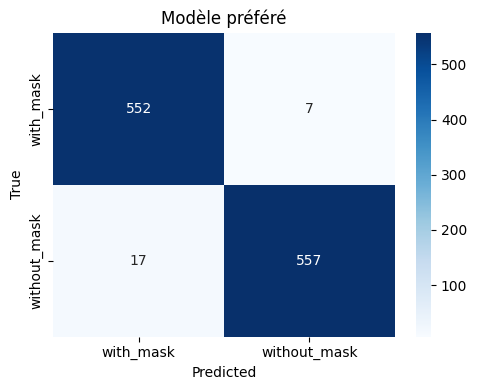

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

preferred_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax'),
])
preferred_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

history_preferred = preferred_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=8,
    batch_size=32,
    verbose=1,
)

preferred_metrics = evaluate_model(preferred_model, X_test, y_test, 'Modèle préféré')

## Interprétation de la comparaison

Le modèle basé sur `MobileNetV2` part d'un extracteur de caractéristiques déjà appris sur ImageNet. Sur ce problème, cela aide souvent quand le jeu de données est limité ou bruité, car le réseau n'a pas besoin de réapprendre des bords, des textures et des formes simples à partir de zéro.

L'ajout d'augmentation de données (`RandomFlip`, `RandomRotation`, `RandomZoom`) vise à réduire le sur-apprentissage. Si le modèle préféré progresse surtout en validation et en test, cela confirme qu'il généralise mieux que le CNN de référence.

En cas d'écart faible entre les deux modèles, il faut privilégier celui qui reste plus stable sur plusieurs exécutions et qui produit le moins d'erreurs sur la classe la plus critique pour l'usage final.

## 6. Sélectionner et sauvegarder le meilleur modèle

On sauvegarde le modèle qui obtient la meilleure précision sur le jeu de test, pour l'utiliser ensuite dans l'API.

In [9]:
best_model_name = 'current' if current_metrics['accuracy'] >= preferred_metrics['accuracy'] else 'preferred'
best_model = current_model if best_model_name == 'current' else preferred_model
best_path = MODELS_DIR / 'selected_mask_model.keras'
best_model.save(best_path)

print('Best model:', best_model_name)
print('Saved to  :', best_path)


def predict_single_image(model: tf.keras.Model, image_path: str | Path) -> dict[str, float | str]:
    image = Image.open(image_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    array = np.asarray(image, dtype=np.float32) / 255.0
    prediction = model.predict(array[None, ...], verbose=0)[0]
    class_index = int(np.argmax(prediction))
    return {
        'label': label_encoder.classes_[class_index],
        'confidence': float(prediction[class_index]),
    }

print('Pour l'"'"'API, pointe MASK_MODEL_PATH vers selected_mask_model.keras si ce modèle est retenu.')

Best model: preferred
Saved to  : /content/C:/Users/yassi/OneDrive/Bureau/Portfolio/plugins/mask-detection-cnn/models/selected_mask_model.keras
Pour l'API, pointe MASK_MODEL_PATH vers selected_mask_model.keras si ce modèle est retenu.


## Conclusion du choix

Le modèle retenu est celui qui servira ensuite d'artefact applicatif dans l'API. L'idée n'est pas seulement de sauver celui qui a la meilleure accuracy sur un seul split, mais de conserver le compromis le plus crédible entre performance globale, stabilité et qualité des erreurs.

Le fichier `selected_mask_model.keras` devient la référence à brancher dans le projet de démo. Si de nouveaux tests montrent qu'un autre modèle fait mieux sur les images réelles, il suffira de réexécuter ce notebook pour régénérer le modèle sélectionné sans toucher au reste de l'architecture.